# Regresión lineal múltiple

## Repaso - regresión lineal simple

$$ y = \beta_0 + \beta_1 x_1 + \varepsilon $$

- $y$ = variable dependiente (lo que queremos explicar)
- $x_1$ = variable independiente
- $\beta_1$ = cambio promedio en $Y$ por una unidad de $X$
- $\varepsilon$ = factores no observados

## El problema de las variables omitidas

¿Qué sucede con lo que queda en el error? ¿Qué problema se puede generar? ¿Cómo solucionarlo?

Supongamos que hacemos una regresión con VD = Salario y VI = Educación.

Ya vimos que cuando una variable omitida (no incluida en el modelo) se relaciona tanto con X como con Y &rarr; **Sesgo por variable omitida**.

## El problema de las variables omitidas

Pensemos en una muestra con personas de edades 16-50 años…

¿Qué esperan que suceda con el $\beta_1$ de la educación? ¿Va a representar el efecto "real" que tiene la educación sobre el salario o podría resultar sesgado?

## El problema de las variables omitidas

En teoría, educación y experiencia podrían estar correlacionadas positiva o negativamente.

- **Positivamente:** en tanto que a medida que aumenta la edad también lo hacen la experiencia y la educación.
- **Negativamente:** personas que tardan más en ingresar al mercado de trabajo porque se dedican a estudiar (probablemente en edades más jóvenes).

## El problema de las variables omitidas

Independientemente del sesgo de la estimación del efecto de la educación sobre el salario que produce no incorporar la experiencia, el problema nos plantea la relevancia de incorporar esta variable relevante como **variable de control** en nuestro modelo.

## El problema de las variables omitidas

Entonces, una posible solución es pasar de una regresión lineal simple a una **múltiple** que nos permita incorporar más de un regresor.

## Ecuación general de la regresión lineal múltiple

$$ Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \dots + \beta_k X_{ki} + \varepsilon_i $$

$k$ indica la cantidad de variables explicativas, por lo que tendremos $k$ regresores.

## Ecuación aplicada a nuestro ejemplo

$$ \text{Salario}_i = \beta_0 + \beta_1 \text{Educación}_i + \beta_2 \text{Experiencia}_i + \varepsilon_i $$

Este nuevo modelo me permite preguntarme acerca del "efecto" de la educación sobre el salario independientemente de la experiencia del individuo, o manteniéndola constante. Suele decirse que se **controla** por la variable porque estamos viendo, a igual nivel de experiencia, cuál es el efecto de la educación.

## ¿Qué sucede en los datos?

Aplicamos la regresión lineal múltiple al **Quality of Government (QoG) Basic dataset** (un país por fila), dando continuidad al ejemplo de regresión lineal simple.

Nos preguntamos por los determinantes de la **percepción de corrupción** (CPI, de Transparency International, 0 = muy corrupto a 100 = muy transparente). En la clase de RLS vimos que el PBI per cápita se asocia con menor corrupción. Ahora incorporamos un segundo regresor —el nivel de **democracia**— como variable de control, para ver el efecto del PBI *manteniendo constante* el régimen político.

$$ \text{CPI}_i = \beta_0 + \beta_1 \log(\text{PBI per cápita})_i + \beta_2 \text{democracia}_i + \varepsilon_i $$

## Librerías y datos

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
qog = pd.read_stata("qog_bas_cs_jan26.dta", convert_categoricals=False)

datos = (qog[["cname", "ti_cpi", "wdi_gdpcapcon2015", "vdem_polyarchy"]]
         .rename(columns={"ti_cpi": "cpi",
                          "wdi_gdpcapcon2015": "pbi",
                          "vdem_polyarchy": "democracia"})
         .dropna())
datos["log_pbi"] = np.log(datos["pbi"])

print("Países con datos completos:", len(datos))
datos.head()

Países con datos completos: 167


,cname,cpi,pbi,democracia,log_pbi
0,Afghanistan,24.0,377.665627,0.076,5.934009
1,Albania,36.0,5867.650962,0.520,8.677210
2,Algeria,33.0,4544.466881,0.267,8.421666
4,Angola,33.0,2860.902519,0.327,7.958892
6,Azerbaijan,23.0,5599.585250,0.185,8.630448


## Matriz de correlación

Antes de estimar el modelo, miramos cómo se asocian entre sí las variables.

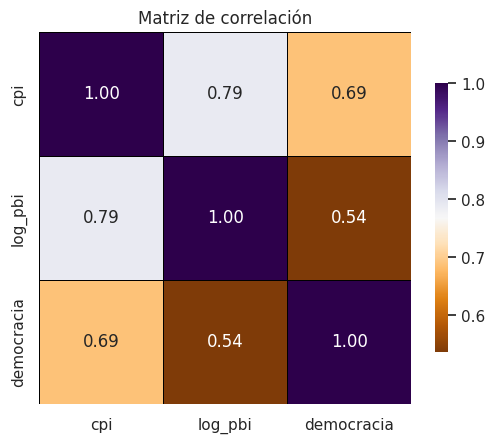

In [3]:
cor_matrix = datos[["cpi", "log_pbi", "democracia"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(cor_matrix, annot=True, cmap="PuOr", square=True, fmt=".2f",
            linewidths=0.5, linecolor="black", cbar_kws={"shrink": .7})
plt.title("Matriz de correlación")
plt.show()

## De la regresión simple a la múltiple

Partimos del modelo simple visto en RLS: la corrupción explicada solo por el (log del) PBI per cápita.

In [4]:
X1 = sm.add_constant(datos["log_pbi"])
modelo_simple = sm.OLS(datos["cpi"], X1).fit()
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     273.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           8.17e-37
Time:                        03:24:16   Log-Likelihood:                -641.49
No. Observations:                 167   AIC:                             1287.
Df Residuals:                     165   BIC:                             1293.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -44.8074      5.384     -8.322      0.0

Ahora incorporamos la **democracia** como variable de control (regresión múltiple):

In [5]:
X = sm.add_constant(datos[["log_pbi", "democracia"]])
modelo = sm.OLS(datos["cpi"], X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     211.8
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.59e-46
Time:                        03:24:16   Log-Likelihood:                -616.46
No. Observations:                 167   AIC:                             1239.
Df Residuals:                     164   BIC:                             1248.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.3202      4.782     -7.595      0.0

**Sesgo por variable omitida en los datos.** El coeficiente del log del PBI **cae** al pasar del modelo simple al múltiple (de ~10 a ~7,6): parte de lo que en la regresión simple se atribuía al PBI en realidad correspondía a la democracia, que estaba omitida y se relaciona tanto con el PBI como con la corrupción. En el modelo múltiple, $\beta_1$ mide el efecto del PBI **controlando por** (a igual nivel de) democracia, y $\beta_2$ el efecto de la democracia controlando por el PBI. El $R^2$ además aumenta al sumar el segundo regresor.

## Supuestos

Estimado el modelo, evaluamos los supuestos que deben cumplir los residuos para que los estimadores sean "buenos".

### Supuesto 1 - Normalidad de los errores

El promedio esperado de los residuos debe ser $0$: $E(\varepsilon) = 0$.

In [6]:
resid_val = modelo.resid
fitted_val = modelo.predict()

# E(resid) = 0
resid_val.mean()

np.float64(2.393295142904529e-14)

Evaluamos la normalidad de los residuos con un **QQ-plot**, tests de normalidad y el histograma con su curva de densidad.

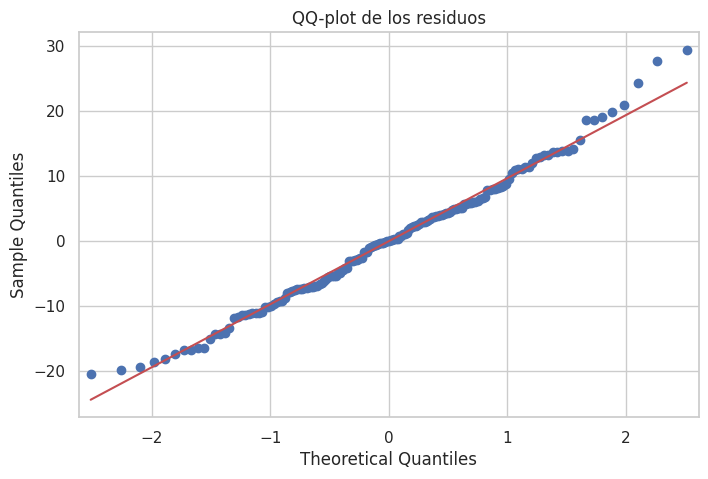

In [7]:
sm.qqplot(resid_val, line="s")
plt.title("QQ-plot de los residuos")
plt.show()

In [8]:
# Test de Shapiro-Wilk
shapiro_test = stats.shapiro(resid_val)
print(f"Shapiro-Wilk test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# Test de Kolmogorov-Smirnov
ks_test = stats.kstest(resid_val, 'norm', args=(np.mean(resid_val), np.std(resid_val)))
print(f"Kolmogorov-Smirnov test: D={ks_test.statistic:.4f}, p-value={ks_test.pvalue:.4f}")

Shapiro-Wilk test: W=0.9895, p-value=0.2535
Kolmogorov-Smirnov test: D=0.0409, p-value=0.9318


Cuando hay un conflicto entre estas dos pruebas, tiende a considerarse que **Shapiro-Wilk** es más confiable para muestras más pequeñas, mientras que **Kolmogorov-Smirnov** puede ser más adecuado para muestras más grandes. En ambos casos, la hipótesis nula es que los datos siguen una distribución normal: un $p$-value alto indica que **no podemos rechazar la normalidad**.

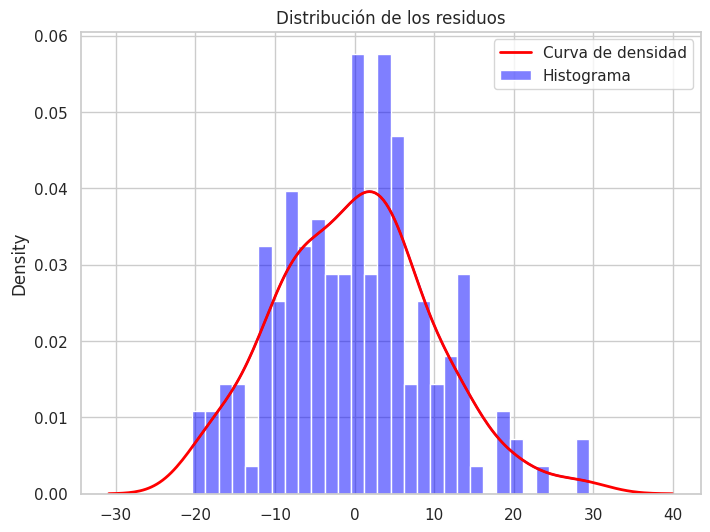

In [9]:
# Histograma con curva de densidad de los residuos
plt.figure(figsize=(8, 6))
sns.histplot(resid_val, kde=True, stat="density", color="blue", bins=30, label="Histograma")
sns.kdeplot(resid_val, color="red", lw=2, label="Curva de densidad")
plt.title("Distribución de los residuos")
plt.legend()
plt.show()

### Supuesto 2 - Homocedasticidad o igualdad de varianzas

Graficamos los valores ajustados contra los residuos. Lo importante en este punto es que **no haya un patrón** (la varianza de los residuos debe ser constante).

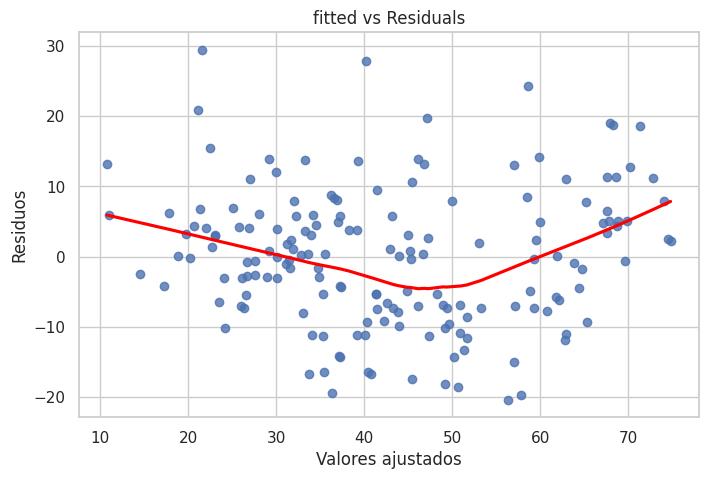

In [10]:
sns.regplot(x=fitted_val, y=resid_val, lowess=True, line_kws={"color": "red"})
plt.title("fitted vs Residuals")
plt.xlabel("Valores ajustados"); plt.ylabel("Residuos")
plt.show()

Es mejor utilizar **residuos estandarizados**.

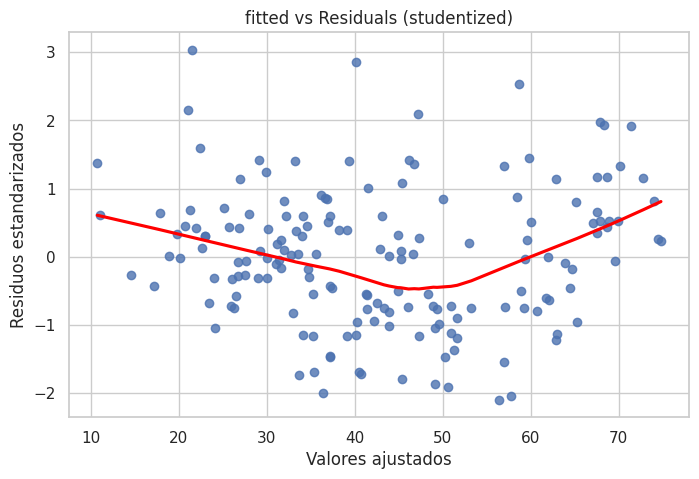

In [11]:
resid_stand = modelo.get_influence().resid_studentized_internal

sns.regplot(x=fitted_val, y=resid_stand, lowess=True, line_kws={"color": "red"})
plt.title("fitted vs Residuals (studentized)")
plt.xlabel("Valores ajustados"); plt.ylabel("Residuos estandarizados")
plt.show()

Complementamos el análisis gráfico con el test de **Breusch-Pagan**, cuya hipótesis nula es la homocedasticidad: un $p$-value alto indica que no podemos rechazarla.

In [12]:
bp_test = het_breuschpagan(resid_val, modelo.model.exog)
print("Breusch-Pagan test: p-value =", round(bp_test[1], 4))

Breusch-Pagan test: p-value = 0.2138


### Supuesto 3 - No multicolinealidad

El **Variance Inflation Factor (VIF)** es una medida que evalúa la colinealidad entre variables independientes en un modelo de regresión. Un VIF alto indica que una variable está altamente correlacionada con otras variables independientes, lo cual puede inflar la varianza de los coeficientes y hacer que el modelo sea inestable o que sus coeficientes sean difíciles de interpretar.

**Interpretación básica:**

- **VIF = 1**: No hay colinealidad.
- **VIF entre 1 y 5**: Colinealidad moderada; generalmente aceptable.
- **VIF > 5 o 10**: Colinealidad alta; podría ser problemático y sugiere considerar la eliminación o combinación de variables.

In [13]:
X_no_const = X.drop(columns=["const"])
vif = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
vif_modelo = pd.DataFrame({"VIF": vif}, index=X_no_const.columns)
vif_modelo

,VIF
log_pbi,6.60329
democracia,6.60329


El PBI per cápita y la democracia están correlacionados (los países más ricos tienden a ser más democráticos), lo que se refleja en un VIF por encima de 5: hay colinealidad moderada-alta a tener en cuenta al interpretar los coeficientes.

El modelo de regresión propuesto solo sirve para estimar dentro del rango de valores propuestos en la muestra.